## Exploratory analysis of rent prices dataset

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rent_regions = pd.read_csv("../data/processed/private_rents_regions.csv")

rent_regions.head()

,time_period,area_code,area_name,region_or_country_name,index,monthly_change,annual_change,rental_price
0,2015-01-01,K02000001,United Kingdom,NaN,81.258259,NaN,NaN,910.0
1,2015-02-01,K02000001,United Kingdom,NaN,81.413747,0.191351,NaN,912.0
2,2015-03-01,K02000001,United Kingdom,NaN,81.663685,0.306997,NaN,915.0
3,2015-04-01,K02000001,United Kingdom,NaN,81.990506,0.400204,NaN,918.0
4,2015-05-01,K02000001,United Kingdom,NaN,82.343646,0.430708,NaN,922.0


In [4]:
# Convert the date
rent_regions["time_period"] = pd.to_datetime(rent_regions["time_period"])

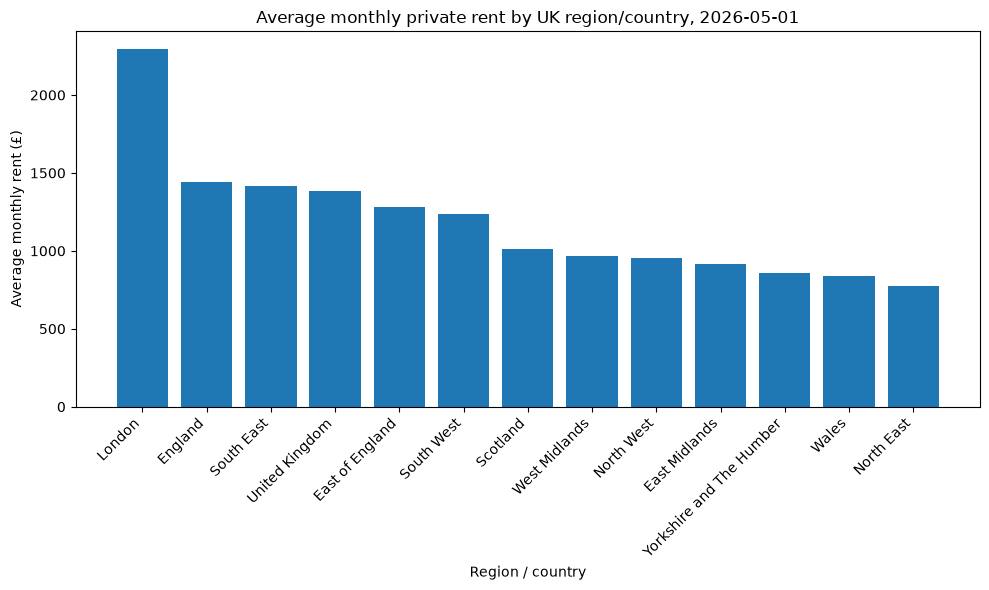

In [6]:
# Creation of first chart

latest_date = rent_regions["time_period"].max()

latest_rents = rent_regions[rent_regions["time_period"] == latest_date]

latest_rents = latest_rents.sort_values("rental_price", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(latest_rents["area_name"], latest_rents["rental_price"])
plt.title(f"Average monthly private rent by UK region/country, {latest_date.date()}")
plt.xlabel("Region / country")
plt.ylabel("Average monthly rent (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/latest_average_rent_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

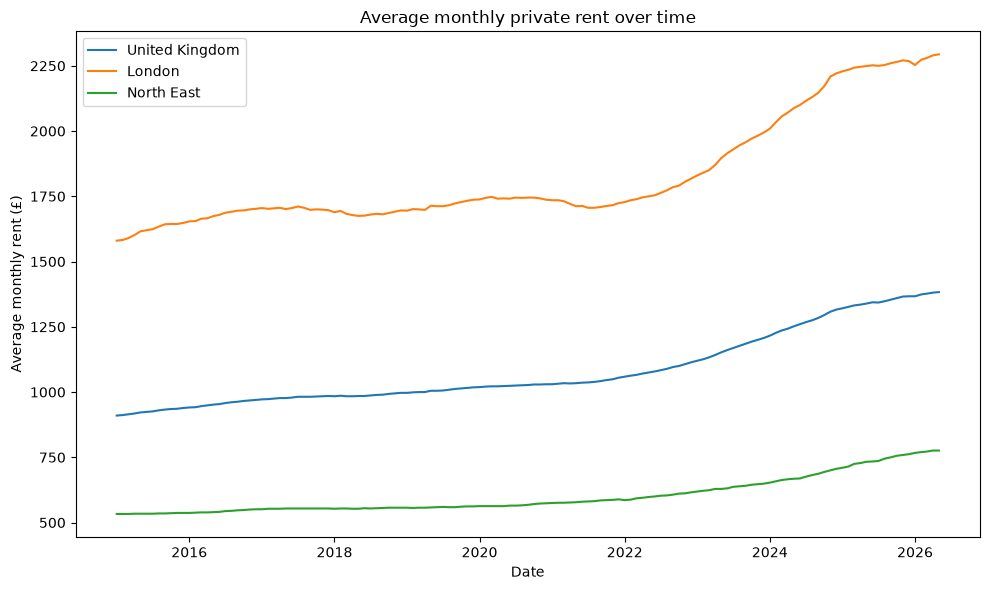

In [8]:
#Rent over time visual

selected_regions = ["United Kingdom", "London", "North East"]

rent_selected = rent_regions[
    rent_regions["area_name"].isin(selected_regions)
].copy()

plt.figure(figsize=(10, 6))

for region in selected_regions:
    region_data = rent_selected[rent_selected["area_name"] == region]
    plt.plot(
        region_data["time_period"],
        region_data["rental_price"],
        label=region
    )

plt.title("Average monthly private rent over time")
plt.xlabel("Date")
plt.ylabel("Average monthly rent (£)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../outputs/charts/rent_trends_selected_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Rent growth by region

rent_growth = (
    rent_regions
    .sort_values("time_period")
    .groupby("area_name")
    .agg(
        first_date=("time_period", "first"),
        latest_date=("time_period", "last"),
        first_rent=("rental_price", "first"),
        latest_rent=("rental_price", "last")
    )
    .reset_index()
)

rent_growth["rent_growth_percent"] = (
    (rent_growth["latest_rent"] - rent_growth["first_rent"])
    / rent_growth["first_rent"]
) * 100

rent_growth = rent_growth.sort_values("rent_growth_percent", ascending=False)

rent_growth

,area_name,first_date,latest_date,first_rent,latest_rent,rent_growth_percent
6,Northern Ireland,2015-01-01,2026-03-01,532.0,876.0,64.661654
0,East Midlands,2015-01-01,2026-05-01,566.0,914.0,61.484099
5,North West,2015-01-01,2026-05-01,594.0,954.0,60.606061
1,East of England,2015-01-01,2026-05-01,800.0,1280.0,60.000000
9,South West,2015-01-01,2026-05-01,778.0,1234.0,58.611825
12,West Midlands,2015-01-01,2026-05-01,615.0,966.0,57.073171
11,Wales,2015-01-01,2026-05-01,541.0,836.0,54.528651
8,South East,2015-01-01,2026-05-01,932.0,1418.0,52.145923
10,United Kingdom,2015-01-01,2026-05-01,910.0,1383.0,51.978022
2,England,2015-01-01,2026-05-01,950.0,1442.0,51.789474


In [10]:
rent_growth.to_csv(
    "../data/processed/rent_growth_by_region.csv",
    index=False
)

### Initial insight

The latest rent data shows clear regional differences in average monthly private rent, with London considerably higher than other UK regions. The next stage of the project will compare these rent trends with wage data to assess whether affordability has worsened over time.

## Exploritory analysis of affordability dataset

In [11]:
affordability = pd.read_csv("../data/processed/affordability_data.csv")

affordability["time_period"] = pd.to_datetime(affordability["time_period"])

affordability.head()

,time_period,area_code,area_name,region_or_country_name,index,monthly_change,annual_change,rental_price,median_monthly_pay,rent_to_pay_percent
0,2015-01-01,K02000001,United Kingdom,NaN,81.258259,NaN,NaN,910.0,1618,56.242274
1,2015-02-01,K02000001,United Kingdom,NaN,81.413747,0.191351,NaN,912.0,1620,56.296296
2,2015-03-01,K02000001,United Kingdom,NaN,81.663685,0.306997,NaN,915.0,1622,56.411837
3,2015-04-01,K02000001,United Kingdom,NaN,81.990506,0.400204,NaN,918.0,1613,56.912585
4,2015-05-01,K02000001,United Kingdom,NaN,82.343646,0.430708,NaN,922.0,1616,57.054455


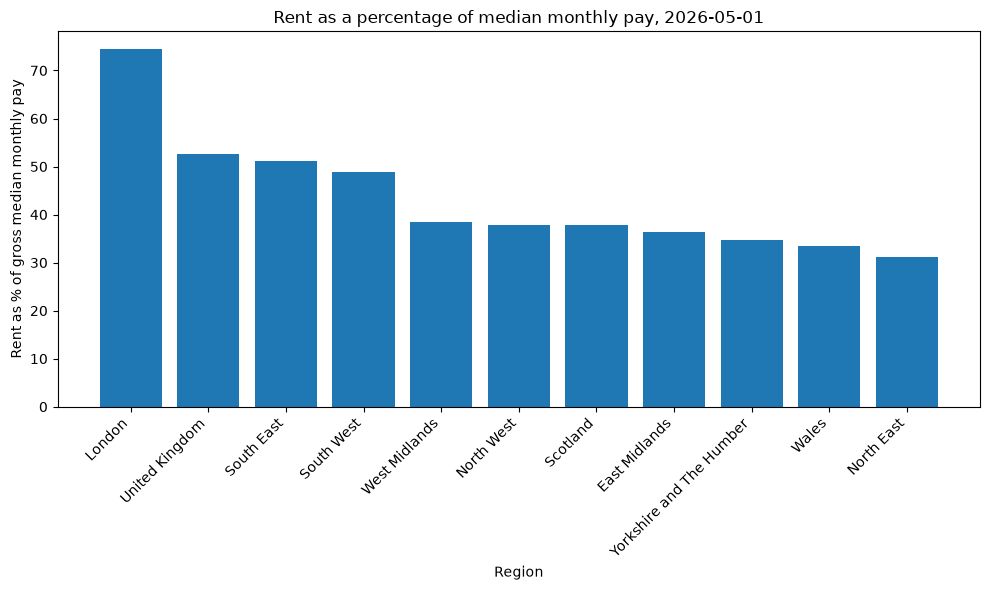

In [13]:
# Affordability bar graph

latest_date = affordability["time_period"].max()

latest_affordability = affordability[
    affordability["time_period"] == latest_date
].sort_values("rent_to_pay_percent", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(
    latest_affordability["area_name"],
    latest_affordability["rent_to_pay_percent"]
)

plt.title(f"Rent as a percentage of median monthly pay, {latest_date.date()}")
plt.xlabel("Region")
plt.ylabel("Rent as % of gross median monthly pay")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    "../outputs/charts/rent_as_percentage_of_median_pay.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()